<a href="https://colab.research.google.com/github/Blank-game/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
#starting section 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/main/Lab2/yellow_tripdata.csv")

print(df.shape)
df.head()


(41202, 13)


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


In [71]:
print (df.dtypes) #print data type of each column
print ("\n") #print a blank line to make the output easier to read
print (df.isnull().sum()) #count how many values are missing for each column
print ("\n") #another blank line for readability
print (df.describe())

VendorID                   int64
passenger_count            int64
trip_distance            float64
RatecodeID                 int64
store_and_fwd_flag         int64
PULocationID               int64
DOLocationID               int64
payment_type               int64
fare_amount              float64
mta_tax                  float64
tolls_amount             float64
improvement_surcharge      int64
tip_amount               float64
dtype: object


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


       VendorID  passenger_count  ...  improvement_surcharge    tip_amount
count   41202.0     41202.000000  ...           41202.000000  41202.000000
mean        2.0         1.633926  ...  

In [72]:
df = df[df['trip_distance'] > 0] #removing rows where trip_distance is 0 or < 0 for individual trips
df = df.drop(columns=['VendorID', 'payment_type']) #dropping columns with the same value in every row
print (df.shape) #confirming the shape of the data after the data cleaning

(41126, 11)


In [73]:
df['total_cost'] = df['fare_amount'] + df['mta_tax'] + df['improvement_surcharge'] #creating new column for total trip cost
df['cost_per_mile'] = df['total_cost'] / (df['trip_distance'] + 1e-9) #creating new column for cost per mile. 1e-9 is added to trip distance to avoid division by 0
print(df.shape)
df[['total_cost', 'cost_per_mile', 'tip_amount']].head() #gives us a preview of the columns (the new ones)



(41126, 13)


,total_cost,cost_per_mile,tip_amount
0,71.5,4.055587,16.54
1,71.5,3.662910,16.19
2,71.5,4.014599,12.00
3,71.5,3.704663,5.00
4,71.5,3.813333,10.00


In [74]:
from sklearn.model_selection import train_test_split #importing tool for splitting data

x = df.drop(columns= ['tip_amount']) #all but tip_amount
y = df['tip_amount'] #nothing but tip_amount
#the 2 lines above basically just separate features (x) from the target we are trying to predict (y)

x_temp, x_test, y_temp, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42) #this is our first split; test: take out 20%, keep 80%
x_train, x_val, y_train, y_val = train_test_split(x_temp, y_temp, test_size= 0.25, random_state = 42) #second split; 80% becomes 60% train and 20% validation

print ("Train size:", x_train.shape)
print ("validation size:", x_val.shape)
print ("test size:", x_test.shape)



Train size: (24675, 12)
validation size: (8225, 12)
test size: (8226, 12)


In [75]:
from sklearn.ensemble import RandomForestRegressor #importing randomforestregressor model

model = RandomForestRegressor(n_estimators= 100, random_state= 42) #build 100 decision trees and average predictions (random_state makes sure we get the same result every time we run the model)

model.fit(x_train, y_train) #train model using training data; it learns relationshiop between features and tips (x_train, y_train respectively)

print("The model has been trained")

The model has been trained


In [76]:
from sklearn.metrics import mean_squared_error, r2_score #import evaluation metrics


y_pred_train = model.predict(x_train) #predictions on training data
y_pred_val = model.predict(x_val) #predictions on validation data
y_pred_test = model.predict(x_test) #predictions on test data

#now calculate Root Mean Squared Error (RMSE) for each spilt (sqrt of mean ^2 error)
rmse_train = mean_squared_error(y_train, y_pred_train) ** 0.5
rmse_val = mean_squared_error(y_val, y_pred_val) ** 0.5
rmse_test = mean_squared_error(y_test, y_pred_test) ** 0.5

#calculate r^2 for each split
r2_train = r2_score(y_train, y_pred_train)
r2_val = r2_score(y_val, y_pred_val)
r2_test = r2_score(y_test, y_pred_test)

#print all results
print(f"Train-RMSE: {rmse_train}, R^2: {r2_train}")
print(f"Val-RMSE: {rmse_val}, R^2: {r2_val}")
print(f"Test-RMSE: {rmse_test}, R^2: {r2_test}")

Train-RMSE: 2.8344437436180843, R^2: 0.6698099607221425
Val-RMSE: 5.644725800590905, R^2: -0.1947185991455498
Test-RMSE: 5.608282273901919, R^2: -0.18760257027153449


## Student Reasoning Box

The models shows signs of overfitting. Training Root Mean Squared Error (RMSE) (2.90) is almost half of validation RMSE (5.41) and test RMSE (5.59). The R squared starts at 0.67... on training data and drops to negative vals on unseen data. This could suggest that the model memorised just the training data instead of learning more generally applicable patterns

In [77]:
#beginning section 2

df2 = pd.read_csv("https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/main/Lab2/Obesity_level_prediction_dataset%20(2).csv") #getting the obeisity dataset from github

print(df2.shape) #check the rows and columns

df2.head() #shows preview of a few rows/columns


(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [78]:
#checking for datatypes and missing values
print(df2.dtypes)
print("\n")
print(df2.isnull().sum())
print("\n")

print(df2['NObeyesdad'].value_counts()) #chexk how many people fall into each category (aka. class balance)

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP               

In [79]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df2_encoded = df2.copy() #make a copy of the dataset so as not to damage the original

#encode text columns into numbers e.g. 0 = yes, no =1
le = LabelEncoder()
for col in df2_encoded.select_dtypes(include = 'object').columns:
  df2_encoded[col] = le.fit_transform(df2_encoded[col])

x2 = df2_encoded.drop(columns=['NObeyesdad']) #again; separating features (x) from targets (y) excluding the target
y2 = df2_encoded['NObeyesdad']


scaler = StandardScaler() #scale features for similar column range
x2_scaled = scaler.fit_transform(x2)

print("Encoded and Sdcaled")
print("x2 shape:", x2.shape)


Encoded and Sdcaled
x2 shape: (2111, 16)


In [80]:
from sklearn.model_selection import train_test_split #for splitting

x2_temp, x2_test, y2_temp, y2_test = train_test_split(x2_scaled, y2, test_size = 0.2, random_state= 42, stratify= y2) #20/80 split making sure categories are proportionally represented in each split(why I'm using stratify)

x2_train, x2_val, y2_train, y2_val = train_test_split(x2_temp, y2_temp, test_size= 0.25, random_state= 42, stratify= y2_temp) #split the 80 split leaving 60/20 (train/validation)

print("train size:", x2_train.shape)
print('validation size:', x2_val.shape)
print("test size;", x2_test.shape)

train size: (1266, 16)
validation size: (422, 16)
test size; (423, 16)


In [81]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(n_estimators= 100, random_state= 42) #create model

model2.fit(x2_train, y2_train)

print("classifier has been trained")


classifier has been trained


train - accuracy: 1.0, macro f1: 1.0
val - accuracy: 0.9549763033175356, macro f1: 0.9540678177222555
test - accuracy: 0.9479905437352246, macro f1: 0.9476959370402429


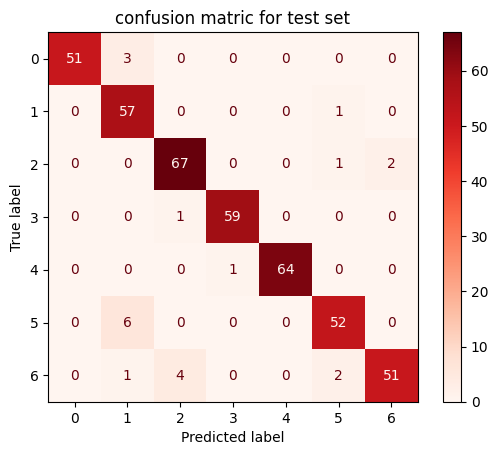

In [82]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay #for evaluation

#using trained model to make predictions on all three splits
y2_pred_train = model2.predict(x2_train)
y2_pred_val = model2.predict(x2_val)
y2_pred_test = model2.predict(x2_test)

#accuracy calculation for each split
acc_train = accuracy_score(y2_train, y2_pred_train)
acc_val = accuracy_score(y2_val, y2_pred_val)
acc_test = accuracy_score(y2_test, y2_pred_test)

#performance calculation across all 7 categories
f1_train = f1_score(y2_train, y2_pred_train, average = 'macro')
f1_val = f1_score(y2_val, y2_pred_val, average = 'macro')
f1_test = f1_score(y2_test, y2_pred_test, average = 'macro')

print(f"train - accuracy: {acc_train}, macro f1: {f1_train}")
print(f"val - accuracy: {acc_val}, macro f1: {f1_val}")
print(f"test - accuracy: {acc_test}, macro f1: {f1_test}")

#plotting confusion matrix for test set
cm = confusion_matrix(y2_test, y2_pred_test)
display = ConfusionMatrixDisplay(confusion_matrix = cm)
display.plot(cmap = "Reds")
plt.title('confusion matric for test set')
plt.show()



##Student Reasoning Box 2
The classifier shows not much overfitting. The training accuracy was at 100 but dropped to 94.8 on the test set. The model still generalised well with macro f1 at 0.948 acrosss all 7 categories. The confusion matrix confirms that most predictions fall on the diagonal , so only a few categories were poorly classified

number of inertia values: 1
inertia values: [33776.0]
number of inertia values: 2
inertia values: [33776.0, 29990.77095142325]
number of inertia values: 3
inertia values: [33776.0, 29990.77095142325, 27368.414371121533]
number of inertia values: 4
inertia values: [33776.0, 29990.77095142325, 27368.414371121533, 25492.438011398754]
number of inertia values: 5
inertia values: [33776.0, 29990.77095142325, 27368.414371121533, 25492.438011398754, 23509.17296151345]
number of inertia values: 6
inertia values: [33776.0, 29990.77095142325, 27368.414371121533, 25492.438011398754, 23509.17296151345, 22337.11499268636]
number of inertia values: 7
inertia values: [33776.0, 29990.77095142325, 27368.414371121533, 25492.438011398754, 23509.17296151345, 22337.11499268636, 20431.27765530878]
number of inertia values: 8
inertia values: [33776.0, 29990.77095142325, 27368.414371121533, 25492.438011398754, 23509.17296151345, 22337.11499268636, 20431.27765530878, 19411.713994863127]
number of inertia values

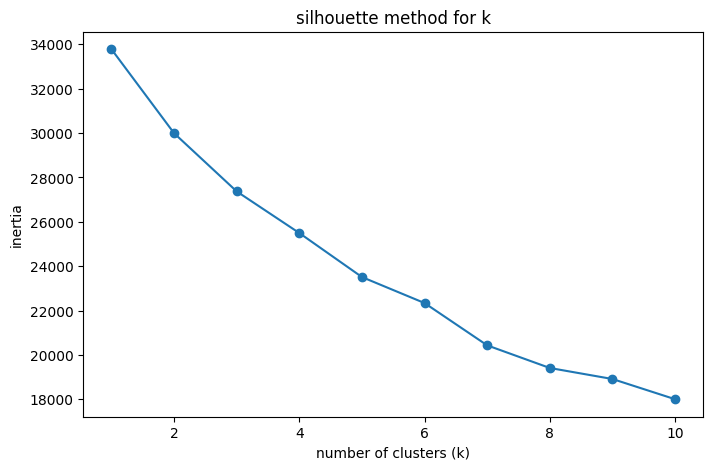

In [83]:
#beginnign section 3
from sklearn.cluster import KMeans #importing KMeans

inertias = []

#using scaled features from section 2 without the labels

for k in range(1, 11):
  km = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  km.fit(x2_scaled)
  inertias.append(km.inertia_)

  #just to confirm that the loop ran correctly
  print('number of inertia values:', len(inertias))
  print('inertia values:', inertias)

#plotting curve
plt.figure(figsize= (8, 5)),
plt.plot(range(1, 11), inertias, marker = 'o')
plt.xlabel('number of clusters (k)')
plt.ylabel('inertia')
plt.title('silhouette method for k')
plt.show()


In [84]:
kmeans = KMeans(n_clusters= 7, random_state= 42, n_init= 10) #match the 7 real categories; fit KMeans with k = 7

kmeans.fit(x2_scaled) #fit model with scaled features (x2_scaled)

clusters = kmeans.labels_ #store clusyer assignment for every individual

print('cluster assignments shape:', clusters.shape)
print('unique clusters:', set(clusters))

cluster assignments shape: (2111,)
unique clusters: {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)}


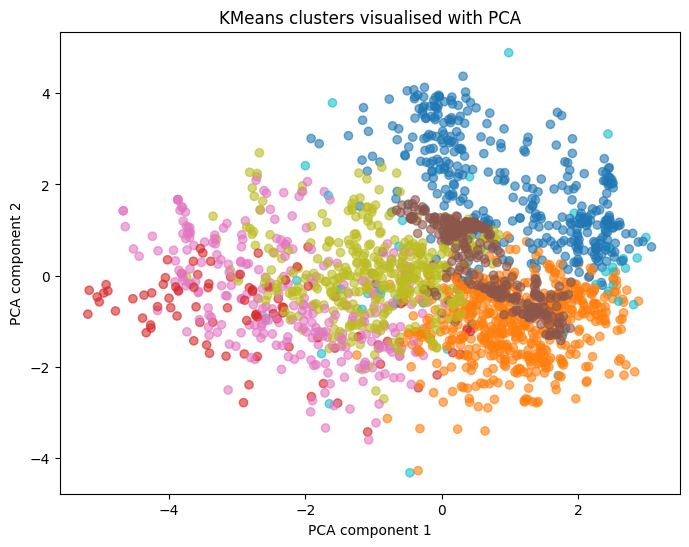

In [85]:
from sklearn.decomposition import PCA #for dimention reduction and visualisation
pca = PCA(n_components= 2)
x2_pca = pca.fit_transform(x2_scaled)

plt.figure(figsize= (8,6))
scatter = plt.scatter(x2_pca[:, 0], x2_pca[:, 1], c= clusters, cmap= 'tab10', alpha= 0.6)
plt.title ('KMeans clusters visualised with PCA')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.show()

In [86]:
import pandas as pd #for crosstab

comparison = pd.DataFrame({ #creating dataframe for comparison between cluster assignments and true labels (true obesity levels)
    'cluster': clusters, #KMeans prediction
    'True Label': y2.values #real category
})

crosstab = pd.crosstab(comparison['cluster'], comparison['True Label'])

print(crosstab)


True Label    0    1    2    3    4   5    6
cluster                                     
0             0   18  108   94    1  55   90
1            74   53  123  134    1  90  107
2            22   27    2    0    0  36    4
3             0    2    6    0  321   8    6
4           127  112    2    1    0  47   10
5            48   62  104   53    0  51   68
6             1   13    6   15    1   3    5


KMeans was able to find some meaningful structure in the data without being given labels. Cluster 3 mapped very well, not perfectly, but close to one true obesity categry, which suggests that group has distinctive features. Other clusters were more mixed.

In [87]:
from sklearn.metrics import silhouette_score

score = silhouette_score(x2_scaled, clusters)
print(f"silhouette score: {score}")

silhouette score: 0.15169586235960947


##Reflection Qs&As

1. Q - Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?

A - The key difference is that the classifier was told what the categories were and leaned to tell the difference between them. K-Means had to figure out groupings and stuff on its own based on patterns in the data. The classifier leanred the exact boundries between all 7 obesity categories becasue it was shown a lot of labelled examples, this was something K-Means couldn't learn. K-Means found that the data has some natural structure even without labels, but the classifier didn't need to lean that

2. Q - Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?

A - Root Mean Squared Error (RMSE) and R^2 was used for regression. Both measured how close the predicted amount was to the real amount. The error is continuous; basically, being off by a dollar vs being off by 10 both matter, just not in the same way. For classification, accuracy and F1 were used to tell if the category was gotten corerectly or not; not much room for error.

3. Q - Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

A - The biggest gap was from Regression where R^2 went from 0.67 to negative something on test, and RMSE almost doubled. To close it, I would limit the depth of the treets in the random forest, I think doing this would help stop the model from "memorising" the training data by stopping the trees from getting to complex